# 05b — LSTM Around the 2021 Silver Squeeze

The January 2021 WallStreetBets silver squeeze is the central event motivating
the retail-driven price hypothesis. The standard train/test split places the squeeze
**inside the training set** (train: 2015–2021, test: 2023–2024), so notebook 05
never evaluates on it out-of-sample.

This notebook retrains on **pre-squeeze data only** (2015–2020) and forecasts
through 2021 — a genuine out-of-sample test on the event the thesis is about.

**Key question:** does adding Reddit sentiment improve directional accuracy
specifically during the squeeze period, when retail activity was at its peak?

Sub-periods analysed:
- Pre-squeeze 2021: 2021-01-01 → 2021-01-27
- Squeeze peak:     2021-01-28 → 2021-02-05
- Post-squeeze:     2021-02-06 → 2021-06-30
- Rest of 2021:     2021-07-01 → 2021-12-31


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: mps


## 1. Hyperparameters

In [2]:
SEQ_LEN  = 20
HORIZON  = 1
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.3
EPOCHS   = 100
LR       = 1e-4
PATIENCE = 10
BATCH    = 32
TARGET   = 'silver_return'

# Squeeze event dates
SQUEEZE_START = pd.Timestamp('2021-01-28')
SQUEEZE_END   = pd.Timestamp('2021-02-05')


## 2. Load data & pre-squeeze split

The full training set covers 2015–2021. We split it into:
- **Pre-squeeze train**: 2015-01-05 → 2020-10-31 (~1,450 days)
- **Pre-squeeze val**: 2020-11-01 → 2020-12-31 (~45 days, for early stopping)
- **Squeeze test**: 2021-01-01 → 2021-12-31 (~261 days, the full squeeze year)


In [3]:
# Load full training-period data (2015–2021)
full = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)

# Merge sentiment
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    for col in ['reddit_sentiment', 'news_sentiment']:
        full[col] = sent[col].reindex(full.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    full['reddit_sentiment'] = 0.0
    full['news_sentiment']   = 0.0

# Pre-squeeze splits
train_df = full[full.index < '2020-11-01']
val_df   = full[(full.index >= '2020-11-01') & (full.index < '2021-01-01')]
test_df  = full[full.index >= '2021-01-01']   # full 2021 squeeze year

print(f'Pre-squeeze train: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train_df)} days)')
print(f'Pre-squeeze val:   {val_df.index[0].date()}   → {val_df.index[-1].date()}  ({len(val_df)} days)')
print(f'Squeeze test:      {test_df.index[0].date()}  → {test_df.index[-1].date()}  ({len(test_df)} days)')

# Feature set — all available except raw price level and combined sentiment
EXCLUDE = {'silver', 'sentiment_score', 'reddit_sentiment', 'news_sentiment'}
MARKET_FEATURES = [c for c in full.columns if c not in EXCLUDE]
print(f'Market features ({len(MARKET_FEATURES)}): {MARKET_FEATURES}')


Sentiment merged.
Pre-squeeze train: 2015-01-05 → 2020-10-30  (1461 days)
Pre-squeeze val:   2020-11-02   → 2020-12-31  (42 days)
Squeeze test:      2021-01-04  → 2021-12-31  (252 days)
Market features (34): ['silver_return', 'gold_return', 'copper_return', 'usd_return', 'sp500_return', 'gs_ratio', 'vix_return', 'oil_return', 'silver_lag1', 'silver_lag2', 'silver_lag3', 'silver_lag5', 'silver_lag10', 'silver_vol_5d', 'silver_vol_21d', 'mom_5d', 'mom_21d', 'cpi', 'fed_funds', 'ind_prod', 'm2', 'usd_dxy', 'real_rates', 'cpi_chg', 'fed_funds_chg', 'ind_prod_chg', 'm2_chg', 'usd_dxy_chg', 'real_rates_chg', 'reddit_weight_sum', 'reddit_post_count', 'news_article_count', 'trends_silver', 'trends_silver_ma4']


## 3. LSTM architecture

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


## 4. Training & evaluation helpers

In [5]:
def make_sequences(data, seq_len, target_col, horizon=1):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def evaluate_period(name, actuals, preds, label=''):
    mask = ~np.isnan(preds) & ~np.isnan(actuals)
    if mask.sum() < 5:
        return None
    y_t, y_p = actuals[mask], preds[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    da   = np.mean(np.sign(y_t) == np.sign(y_p))
    wda  = np.sum(np.abs(y_t) * (np.sign(y_t) == np.sign(y_p))) / np.sum(np.abs(y_t))
    tag  = f'[{label}] ' if label else ''
    print(f'{tag}{name:<30}  n={mask.sum():3d}  RMSE={rmse:.5f}  DA={da:.3f}  WDA={wda:.3f}')
    return {'model': name, 'period': label, 'n': int(mask.sum()),
            'rmse': rmse, 'da': da, 'wda': wda}


def run_variant(name, feature_cols):
    print(f'\n{"=" * 55}\nVariant: {name}\n{"=" * 55}')
    cols = [c for c in feature_cols if c in train_df.columns]
    target_idx = cols.index(TARGET)

    scaler  = StandardScaler().fit(train_df[cols].fillna(0))
    tr_s = scaler.transform(train_df[cols].fillna(0))
    va_s = scaler.transform(val_df[cols].fillna(0))
    te_s = scaler.transform(test_df[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx)
    dates = test_df.index[SEQ_LEN:]

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    model = LSTMForecaster(input_size=len(cols)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    ckpt = f'../../data/processed/lstm_squeeze_{name.lower().replace("+","_").replace(" ","_")}.pt'

    best_val, patience_cnt = np.inf, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        bl = []
        for xb, yb in to_loader(X_tr, y_tr):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            bl.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = np.mean([criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in to_loader(X_va, y_va, shuffle=False)])
        scheduler.step(vl)
        if epoch % 20 == 0:
            print(f'  Epoch {epoch:3d}  train={np.mean(bl):.4f}  val={vl:.4f}')
        if vl < best_val:
            best_val, patience_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(torch.load(ckpt))
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for xb, yb in to_loader(X_te, y_te, shuffle=False):
            preds_s.extend(model(xb.to(DEVICE)).cpu().numpy().flatten())
            acts_s.extend(yb.numpy().flatten())

    mu, sigma = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds   = np.array(preds_s) * sigma + mu
    actuals = np.array(acts_s)  * sigma + mu

    return preds, actuals, dates


## 5. Train & forecast

In [6]:
variants = {
    'LSTM-Y':      [TARGET],
    'LSTM-EXOG':   MARKET_FEATURES,
    'LSTM-REDDIT': MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-NEWS':   MARKET_FEATURES + ['news_sentiment'],
}

all_preds   = {}
all_actuals = None
all_dates   = None

for name, features in variants.items():
    preds, actuals, dates = run_variant(name, features)
    all_preds[name] = preds
    all_actuals = actuals
    all_dates   = dates



Variant: LSTM-Y
  Epoch  20  train=0.9650  val=1.6903
  Early stopping at epoch 32

Variant: LSTM-EXOG
  Epoch  20  train=0.9328  val=1.6911
  Epoch  40  train=0.8903  val=1.6744
  Early stopping at epoch 43

Variant: LSTM-REDDIT
  Epoch  20  train=0.9959  val=1.6066
  Epoch  40  train=0.8677  val=1.5799
  Epoch  60  train=0.8597  val=1.5641
  Epoch  80  train=0.8188  val=1.5428
  Epoch 100  train=0.7971  val=1.5338

Variant: LSTM-NEWS
  Epoch  20  train=0.9475  val=1.7479
  Epoch  40  train=0.8792  val=1.7048
  Early stopping at epoch 49


## 6. Sub-period evaluation

The key question: does sentiment help **specifically during the squeeze**?
We split the 2021 forecast window into four periods:
- **Pre-peak**: normal January trading before the squeeze ignited
- **Squeeze peak**: the 9-day window of maximum retail activity
- **Post-squeeze**: the month after the peak as retail interest faded
- **Rest of 2021**: remainder of the year, post-squeeze normalisation


In [7]:
periods = {
    'Pre-peak   (Jan 01–27)':  (pd.Timestamp('2021-01-01'), pd.Timestamp('2021-01-27')),
    'Squeeze peak (Jan 28–Feb 05)': (pd.Timestamp('2021-01-28'), pd.Timestamp('2021-02-05')),
    'Post-squeeze (Feb 06–Jun 30)': (pd.Timestamp('2021-02-06'), pd.Timestamp('2021-06-30')),
    'Rest of 2021 (Jul–Dec)':  (pd.Timestamp('2021-07-01'), pd.Timestamp('2021-12-31')),
    'Full 2021':               (pd.Timestamp('2021-01-01'), pd.Timestamp('2021-12-31')),
}

all_results = []
for period_label, (start, end) in periods.items():
    mask = (all_dates >= start) & (all_dates <= end)
    if mask.sum() < 5:
        continue
    print(f'\n── {period_label} ──')
    for name, preds in all_preds.items():
        r = evaluate_period(name, all_actuals[mask], preds[mask], period_label)
        if r:
            all_results.append(r)

results_df = pd.DataFrame(all_results)
results_df.to_csv('../../data/processed/metrics_lstm_squeeze.csv', index=False)



── Post-squeeze (Feb 06–Jun 30) ──
[Post-squeeze (Feb 06–Jun 30)] LSTM-Y                          n=100  RMSE=0.01620  DA=0.520  WDA=0.480
[Post-squeeze (Feb 06–Jun 30)] LSTM-EXOG                       n=100  RMSE=0.01649  DA=0.430  WDA=0.510
[Post-squeeze (Feb 06–Jun 30)] LSTM-REDDIT                     n=100  RMSE=0.01979  DA=0.400  WDA=0.489
[Post-squeeze (Feb 06–Jun 30)] LSTM-NEWS                       n=100  RMSE=0.01687  DA=0.420  WDA=0.530

── Rest of 2021 (Jul–Dec) ──
[Rest of 2021 (Jul–Dec)] LSTM-Y                          n=128  RMSE=0.01582  DA=0.453  WDA=0.444
[Rest of 2021 (Jul–Dec)] LSTM-EXOG                       n=128  RMSE=0.01597  DA=0.516  WDA=0.555
[Rest of 2021 (Jul–Dec)] LSTM-REDDIT                     n=128  RMSE=0.01863  DA=0.539  WDA=0.586
[Rest of 2021 (Jul–Dec)] LSTM-NEWS                       n=128  RMSE=0.01616  DA=0.516  WDA=0.554

── Full 2021 ──
[Full 2021] LSTM-Y                          n=232  RMSE=0.01761  DA=0.483  WDA=0.447
[Full 2021] LSTM-EXOG   

## 7. Forecast plot — squeeze window

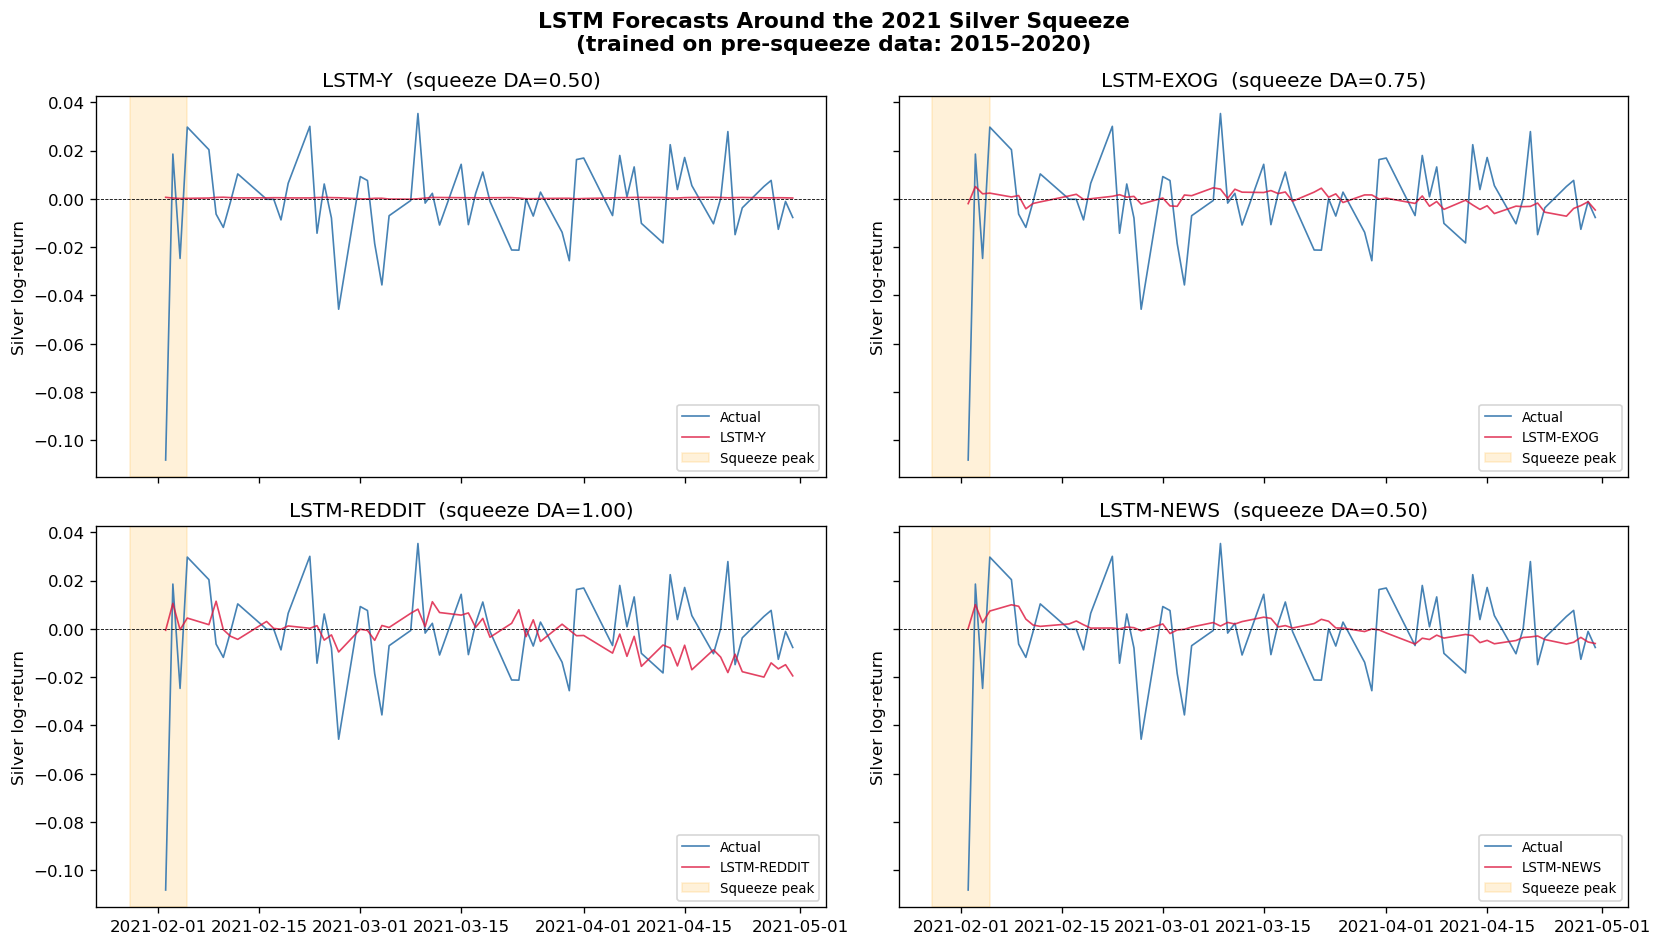

In [8]:
# Focus plot on the squeeze window ±2 months
plot_start = pd.Timestamp('2020-12-01')
plot_end   = pd.Timestamp('2021-04-30')
pmask = (all_dates >= plot_start) & (all_dates <= plot_end)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, preds) in zip(axes, all_preds.items()):
    ax.plot(all_dates[pmask], all_actuals[pmask],
            label='Actual', lw=1, color='steelblue')
    ax.plot(all_dates[pmask], preds[pmask],
            label=name, lw=1, color='crimson', alpha=0.8)
    ax.axvspan(pd.Timestamp('2021-01-28'), pd.Timestamp('2021-02-05'),
               alpha=0.15, color='orange', label='Squeeze peak')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    # DA for squeeze peak only
    smask = (all_dates >= pd.Timestamp('2021-01-28')) & \
            (all_dates <= pd.Timestamp('2021-02-05')) & pmask
    if smask.sum() > 0:
        sda = np.mean(np.sign(all_actuals[smask]) == np.sign(preds[smask]))
        ax.set_title(f'{name}  (squeeze DA={sda:.2f})')
    else:
        ax.set_title(name)
    ax.set_ylabel('Silver log-return')
    ax.legend(fontsize=8)

plt.suptitle('LSTM Forecasts Around the 2021 Silver Squeeze\n'
             '(trained on pre-squeeze data: 2015–2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. DA comparison by period

In [9]:
pivot = results_df.pivot_table(index='model', columns='period', values='da')
# Order columns chronologically
col_order = [c for c in [
    'Pre-peak   (Jan 01–27)', 'Squeeze peak (Jan 28–Feb 05)',
    'Post-squeeze (Feb 06–Jun 30)', 'Rest of 2021 (Jul–Dec)', 'Full 2021'
] if c in pivot.columns]
pivot = pivot[col_order]
print('Directional Accuracy by period:')
print(pivot.round(3).to_string())


Directional Accuracy by period:
period       Post-squeeze (Feb 06–Jun 30)  Rest of 2021 (Jul–Dec)  Full 2021
model                                                                       
LSTM-EXOG                            0.43                   0.516      0.483
LSTM-NEWS                            0.42                   0.516      0.474
LSTM-REDDIT                          0.40                   0.539      0.487
LSTM-Y                               0.52                   0.453      0.483
